In [30]:
from langgraph.graph import START , END , MessagesState , StateGraph
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [31]:
load_dotenv()

True

In [32]:
store=InMemoryStore()
user_id='u1'

In [33]:
user_details=('users',user_id,'details')
store.put(user_details, "profile_1", {"data": "Name: Kabir "})
store.put(user_details, "profile_2", {"data": "Profession: Student at MAIT"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [34]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [45]:
llm=ChatGroq(model='openai/gpt-oss-120b')

In [36]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

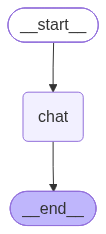

In [37]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [38]:

config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

# Creating Memories through LLM 

In [15]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [16]:
store=InMemoryStore()

In [39]:
extractor_llm=ChatGroq(model='openai/gpt-oss-120b')

In [40]:
class MemoryDecision(BaseModel):
    should_write:bool=Field(description='Whether to send a memory?')
    memories:List[str]=Field(default_factory=list,description='Atomic user memories to store')

In [41]:
memory_extractor=extractor_llm.with_structured_output(MemoryDecision)

In [42]:
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

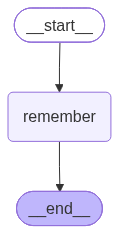

In [43]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [44]:
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Kabir"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [48]:
res = graph.invoke({"messages": [{"role": "user", "content": "I am a Student "}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [47]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is C++ but i prefer python for its world wide implication"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [49]:
items=store.search(('user','u1','details'))
for item in items:
    print(item.value['data'])

The user's name is Kabir.
User's favorite programming language is Python.
User's favorite programming language is C++.
User prefers Python for its worldwide adoption.
The user is a student.


## Chatbot creating new Memories (witohut duplication)

In [50]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [51]:
store=InMemoryStore()

In [52]:
memory_llm=ChatGroq(model='openai/gpt-oss-120b',temperature=0)

In [60]:
class MemoryItem(BaseModel):
    text: str=Field(description='Atomic User memory as a short sentece')
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [61]:
class MemoryDecision(BaseModel):
    should_write: bool =Field(description='Whether to store abny memory?')
    memories : List[MemoryItem]=Field(default_factory=list,description='Atomic user memories to store')

In [72]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [62]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [68]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

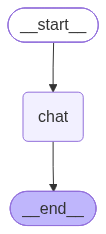

In [69]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)
graph

In [70]:
config={'configurable':{'user_id':'u1'}}

In [77]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Kabir"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [78]:
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [79]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

User's name is Kabir.
User likes Python for programming.
